# `qufin.indicators` Tutorial

An end-to-end walkthrough of the **indicators** subpackage — a
high-performance toolkit of classical technical-analysis primitives,
applied to *real* market data.

The notebook doubles as a primer on the indicators themselves. Each
section opens with the theory (what the indicator measures, how it is
constructed, when it is informative and when it isn't), then turns that
theory into code on a real chart.

**Sections**

0. Loading real data
1. Moving averages — SMA, EMA, WMA, DEMA, TEMA, HMA, KAMA
2. Momentum oscillators — RSI, MACD, Stochastic, ROC, CCI, Williams %R
3. Volatility — true range, ATR, Bollinger, Keltner, Donchian
4. Trend / directional — ADX (+ ±DI), Aroon, Parabolic SAR, Supertrend, Ichimoku
5. Volume — OBV, VWAP, rolling VWAP, MFI, CMF, A/D line
6. Support & resistance — floor pivots (classic + Fibonacci) and swing clustering


## What is technical analysis?

Technical analysis is the discipline of forecasting the *probability
distribution* of future returns from a single observable: the historical
sequence of prices (and, where available, volume). It does **not** ask
*what an asset is worth*; it asks *what other market participants are
likely to do, given what they have already done*.

There are three philosophical premises:

1. **Market action discounts everything.** Whatever fundamentals,
   news, or private information exists, its net effect appears in price.
   The price series is therefore a sufficient statistic — at least
   instrumentally — for whatever you would otherwise need to know.
2. **Prices move in trends.** Once a directional regime is established
   it tends to persist. Mean-reversion exists too, but on shorter
   horizons and inside a trending envelope.
3. **History rhymes.** The patterns produced by crowd behaviour, risk
   limits, and rebalancing are stable enough across time that
   yesterday's structures inform today's odds.

Each premise is empirically debatable. The indicators in this package do
not commit to any of them — they are *transformations of price* that
expose specific structure (trend, momentum, volatility, accumulation,
horizontal levels). Whether to act on that structure is a modelling
choice you make downstream.


### The four families of indicators

Most classical TA primitives fall into one of four families. The
`indicators` subpackage is organised the same way:

| Family | Question it answers | This package |
|---|---|---|
| **Trend / averaging** | Where is the central tendency of price *now*? | `moving_averages`, parts of `trend` |
| **Momentum** | How fast is price changing relative to recent history? | `momentum` |
| **Volatility** | How much is price moving, regardless of direction? | `volatility` |
| **Volume** | How much conviction is behind each move? | `volume` |

A fifth, slightly different group is **structural** — horizontal levels
where supply or demand has historically clustered. Those live in
`support_resistance` and pair naturally with the swing detectors from
`qufin.wyckoff`.

### Why each indicator exists

Every indicator below was invented to fix a perceived blind spot of the
plain price chart:

* **Moving averages** smooth out tick-by-tick noise so the underlying
  trend is visible. Different weighting schemes (simple, exponential,
  Hull, KAMA) trade *lag* against *smoothness*.
* **Oscillators** (RSI, Stochastic, Williams %R) bound a derived
  quantity to a fixed range, making *overbought* and *oversold* states
  comparable across symbols and timeframes.
* **MACD** subtracts a slow EMA from a fast EMA — the result is a
  centred, near-stationary series that highlights *changes in trend
  strength* even when price itself is monotonic.
* **ATR and Bollinger Bands** quantify the *envelope* a typical
  bar lives in. Trading-system position sizing almost always uses
  ATR; option traders use Bollinger width as a poor-man's IV.
* **ADX, Aroon, Supertrend, Parabolic SAR** answer the prior question
  *is there a trend at all?* — without which a trend-following entry
  has no edge.
* **Volume indicators** weight each price move by its trade size, so
  a 0.5 % rally on huge volume reads differently from a 0.5 % rally
  on a quiet tape.
* **Support & resistance** detects the horizontal price *levels* the
  market itself keeps testing, which often coincide with limit orders
  and option strikes.

You will see all of these computed on real NVDA bars below, with the
construction of each laid bare cell-by-cell.


### A note on lag, overfitting, and what to expect

Indicators are *transforms*, not predictions. Two cautions:

1. **Every smoothed indicator lags.** An EMA(20) by construction is
   centred ~10 bars behind price. There is no way around this except
   to use noisier inputs (smaller window) or adaptive weighting (KAMA,
   Hull). Beware any "leading indicator" claim — at best it shifts the
   trade-off rather than escaping it.
2. **Parameter choice matters.** Most of these indicators have one or
   two integer windows. The default values (14 for RSI, 20 for Bollinger,
   etc.) come from historical convention, not first-principles. When
   you build a strategy, the windows are *hyper-parameters* that need
   the same out-of-sample discipline as any ML model.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yfinance as yf

from qufin.indicators import (
    accumulation_distribution,
    # Trend
    adx,
    aroon,
    atr,
    bollinger_bands,
    cci,
    cmf,
    dema,
    donchian_channels,
    ema,
    fibonacci_pivot_points,
    hma,
    ichimoku,
    kama,
    keltner_channels,
    macd,
    mfi,
    # Volume
    obv,
    parabolic_sar,
    # Support / resistance
    pivot_points,
    pivot_points_series,
    roc,
    rolling_vwap,
    # Momentum
    rsi,
    # Moving averages
    sma,
    stochastic,
    supertrend,
    support_resistance_from_swings,
    tema,
    # Volatility
    true_range,
    vwap,
    williams_r,
    wma,
)
from qufin.wyckoff import OHLCV, find_swings

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLOR_UP = '#1f8e3a'
COLOR_DN = '#c4302b'


def load_ohlcv(ticker: str, start: str, end: str, interval: str = '1d') -> OHLCV:
    """Pull bars from yfinance and coerce them into the OHLCV container."""
    raw = yf.download(
        ticker, start=start, end=end, interval=interval,
        auto_adjust=False, progress=False,
    )
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.reset_index()
    ts_col = 'Datetime' if 'Datetime' in raw.columns else 'Date'
    ts = pd.to_datetime(raw[ts_col])
    ts = ts.dt.tz_localize('UTC') if ts.dt.tz is None else ts.dt.tz_convert('UTC')
    pdf = pd.DataFrame({
        'timestamp': ts,
        'open': raw['Open'].astype('float64'),
        'high': raw['High'].astype('float64'),
        'low': raw['Low'].astype('float64'),
        'close': raw['Close'].astype('float64'),
        'volume': raw['Volume'].astype('float64'),
    }).dropna()
    return OHLCV.from_records(pl.from_pandas(pdf), symbol=ticker)


def plot_ohlc(ax, bars: OHLCV, *, width: float = 0.7) -> None:
    """Western OHLC bar chart (wick + open/close ticks)."""
    o, h, l, c = bars.open(), bars.high(), bars.low(), bars.close()
    x = np.arange(o.shape[0])
    up = c >= o
    dn = ~up
    half = width / 2.0
    for mask, color in ((up, COLOR_UP), (dn, COLOR_DN)):
        ax.vlines(x[mask], l[mask], h[mask], color=color, lw=0.8)
        ax.hlines(o[mask], x[mask] - half, x[mask], color=color, lw=0.8)
        ax.hlines(c[mask], x[mask], x[mask] + half, color=color, lw=0.8)


def plot_volume(ax, bars: OHLCV, *, width: float = 0.85) -> None:
    o, c, v = bars.open(), bars.close(), bars.volume()
    x = np.arange(v.shape[0])
    colors = np.where(c >= o, COLOR_UP, COLOR_DN)
    ax.bar(x, v, color=colors, width=width, alpha=0.7)


## 0. Load real data — NVDA daily bars

We use NVIDIA daily bars from 2022-01-01 through 2024-07-01. The window
contains a clean bear leg (2022), a multi-month accumulation
(2022 → early 2023), a violent AI-driven markup (mid 2023 onwards),
and a lateral structure into mid 2024. That mix exercises every
indicator family on the same chart.

If `yfinance` is offline, point the loader at any local file with the
same columns — the rest of the notebook runs unchanged.


In [2]:
bars = load_ohlcv('NVDA', start='2022-01-01', end='2024-07-01')
print(f'{len(bars)} bars, symbol={bars.symbol}')
print(
    f'date range: {bars.data["timestamp"].min()}  '
    f'→  {bars.data["timestamp"].max()}'
)
bars.data.head(3)


625 bars, symbol=NVDA
date range: 2022-01-03 00:00:00+00:00  →  2024-06-28 00:00:00+00:00


timestamp,open,high,low,close,volume
"datetime[ns, UTC]",f64,f64,f64,f64,f64
2022-01-03 00:00:00 UTC,29.815001,30.711,29.785,30.121,3.91547e8
2022-01-04 00:00:00 UTC,30.277,30.468,28.349001,29.290001,5.27154e8
2022-01-05 00:00:00 UTC,28.948999,29.416,27.533001,27.604,4.98064e8


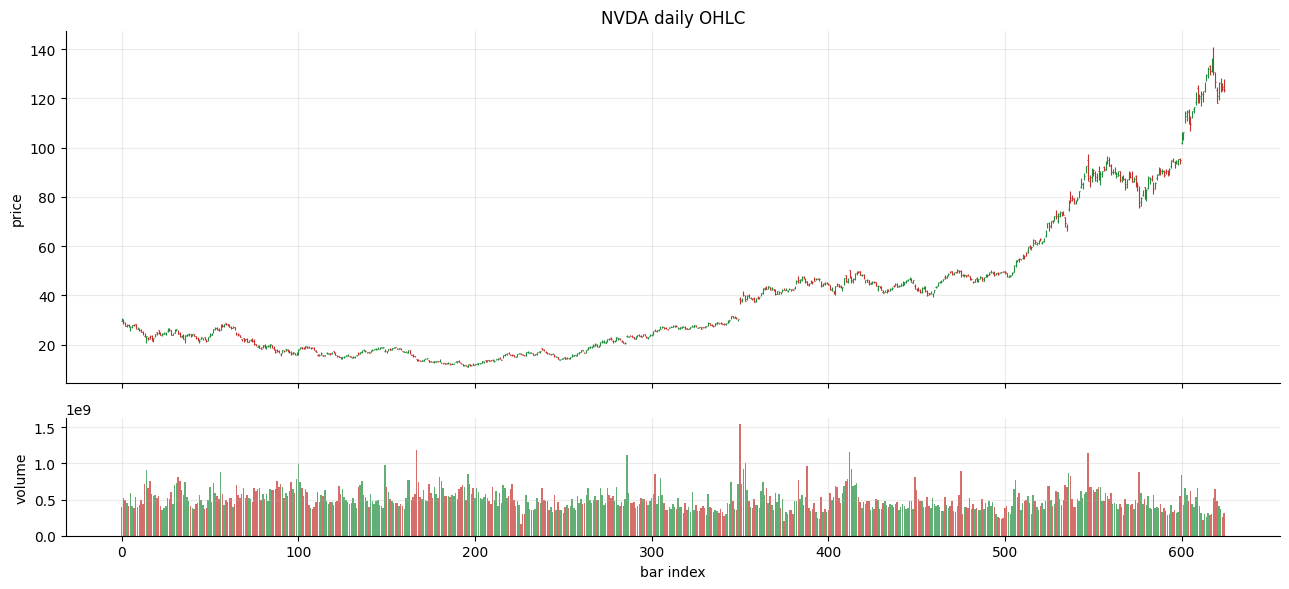

In [3]:
h, l, c, v = bars.high(), bars.low(), bars.close(), bars.volume()
o = bars.open()
n = len(bars)
x = np.arange(n)

fig, (ax_p, ax_v) = plt.subplots(
    2, 1, sharex=True, height_ratios=[3, 1], figsize=(13, 6),
)
plot_ohlc(ax_p, bars)
ax_p.set_title(f'{bars.symbol} daily OHLC')
ax_p.set_ylabel('price')
plot_volume(ax_v, bars)
ax_v.set_ylabel('volume')
ax_v.set_xlabel('bar index')
plt.tight_layout(); plt.show()


## 1. Moving averages

A moving average maps a noisy series `x[t]` to a smoother series `y[t]`
by averaging a *window* of recent samples. The point is to expose the
underlying *trend* — the central tendency around which short-term noise
oscillates.

Every moving average is a compromise between two contradictory goals:

* **Lag** — how many bars behind the live price the average sits.
  Lower is better for early entries.
* **Smoothness** — how aggressively noise is suppressed.
  Higher is better for fewer false signals.

You cannot have both. The averaging schemes below sit at different
points on this trade-off curve.

### Construction

* **SMA(w)** — arithmetic mean of the last `w` samples. All samples
  weight equally; the centroid sits `w/2` bars behind price.
* **EMA(w)** — exponentially-weighted mean. Each bar contributes
  `α·(1−α)^k` where `α = 2/(w+1)`. Weights decay geometrically, so
  the recent past dominates. Effective lag ≈ `(w−1)/2`. Reacts faster
  than SMA at the same window.
* **WMA(w)** — linear weights `1, 2, …, w`. A middle ground: more
  responsive than SMA, less aggressive than EMA.
* **DEMA(w)** — Double EMA = `2·EMA − EMA(EMA)`. Subtracts an
  estimate of the EMA's own lag from the EMA — at the cost of more
  noise.
* **TEMA(w)** — Triple EMA = `3·EMA − 3·EMA(EMA) + EMA(EMA(EMA))`.
  Same idea, second-order correction.
* **HMA(w)** — Hull MA: `WMA(2·WMA(w/2) − WMA(w), √w)`. A near-zero-lag
  WMA construction by Alan Hull. Excellent visual fit; can wiggle in
  ranges.
* **KAMA(w, fast, slow)** — Kaufman's Adaptive MA. The smoothing
  constant is *itself* a function of the *efficiency ratio*
  `ER = |Δ_w| / Σ|Δ_1|`. In a clean trend `ER → 1` and KAMA tracks
  fast; in chop `ER → 0` and KAMA flatlines. The best behaved of the
  bunch in regime mixes.

### When to use which

Trend-following systems usually combine a fast and a slow MA. The
classic *50/200* SMA crossover is the canonical example, but EMA-based
versions react earlier. Hull and KAMA are favoured by discretionary
chartists who want a single line that "just looks right". TEMA and DEMA
are useful as inputs to *other* indicators (e.g. MACD variants) where
you want responsiveness without giving up smoothness entirely.


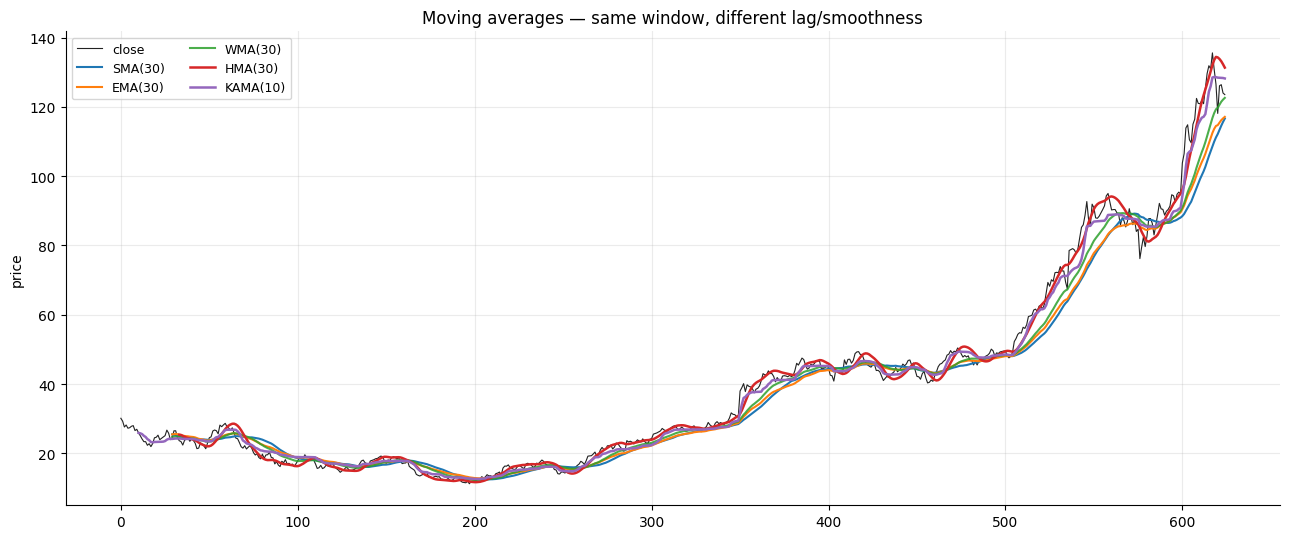

In [4]:
w = 30
ma_sma  = sma(c, w)
ma_ema  = ema(c, w)
ma_wma  = wma(c, w)
ma_dema = dema(c, w)
ma_tema = tema(c, w)
ma_hma  = hma(c, w)
ma_kama = kama(c, window=10, fast=2, slow=30)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(x, c, color='#222', lw=0.8, label='close')
ax.plot(x, ma_sma,  lw=1.5, label=f'SMA({w})')
ax.plot(x, ma_ema,  lw=1.5, label=f'EMA({w})')
ax.plot(x, ma_wma,  lw=1.5, label=f'WMA({w})', alpha=0.85)
ax.plot(x, ma_hma,  lw=1.8, label=f'HMA({w})')
ax.plot(x, ma_kama, lw=1.8, label='KAMA(10)')
ax.set_title('Moving averages — same window, different lag/smoothness')
ax.set_ylabel('price'); ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout(); plt.show()


**Reading the plot.** At a window of 30:

* SMA is the smoothest and reacts last — notice it bottoms in 2023
  weeks after price has already turned up.
* EMA tracks closer to price and turns earlier; WMA sits in between.
* HMA snaps to the price almost without lag but visibly wiggles when
  the trend is unclear (mid-2024).
* KAMA is the most discriminating: nearly flat through the 2022
  consolidation, then steep through the 2023 rally — the adaptive
  smoothing in action.

A useful exercise is to inspect the *lag* numerically by cross-correlating
each MA with the close — the EMA peaks at ~10 bars of lag, the SMA(30)
at ~15.


### DEMA and TEMA — when "less lag" goes too far

DEMA and TEMA *subtract* an estimate of the EMA's lag from the EMA
itself. The result is fast — but also noisier, and prone to overshoot
on reversals.


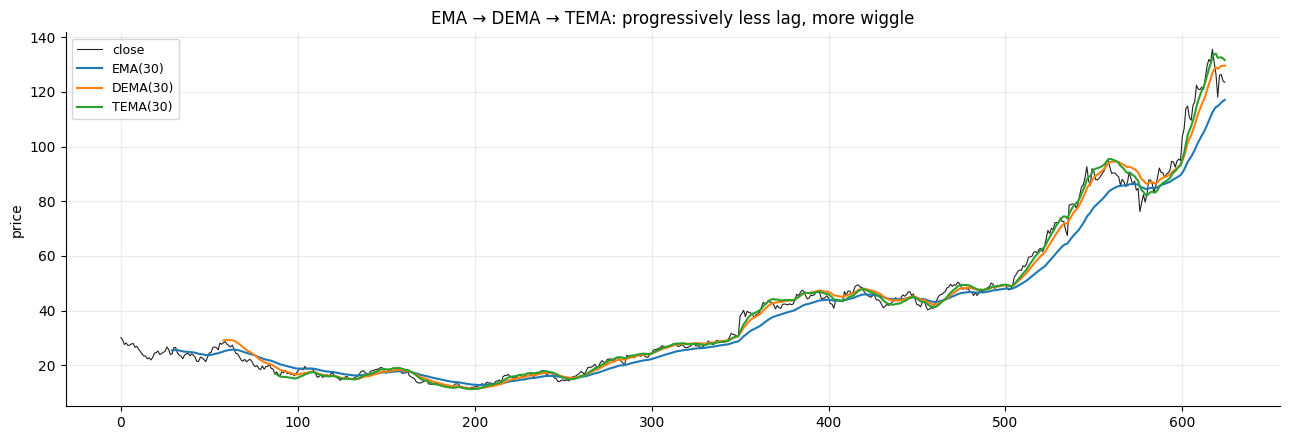

In [5]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(x, c, color='#222', lw=0.8, label='close')
ax.plot(x, ma_ema,  lw=1.5, label=f'EMA({w})')
ax.plot(x, ma_dema, lw=1.5, label=f'DEMA({w})')
ax.plot(x, ma_tema, lw=1.5, label=f'TEMA({w})')
ax.set_title('EMA → DEMA → TEMA: progressively less lag, more wiggle')
ax.set_ylabel('price'); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## 2. Momentum oscillators

A momentum indicator transforms price into a (usually bounded) signal
whose *level* tells you whether recent moves have been strong, weak, or
exhausting. The two diagnostic states are:

* **Overbought / oversold** — the oscillator sits near its extreme,
  suggesting the move that put it there may be running on fumes.
* **Divergence** — price makes a new extreme but the oscillator does
  not, suggesting the new extreme is *unsupported* and may reverse.

Momentum signals are useful but *not* directional by themselves: a
strong trend can keep an RSI pinned at 80 for weeks without reverting.
The right reading is "momentum is hot" rather than "go short now".


### RSI — Relative Strength Index (Wilder, 1978)

Compute the average *gain* `Ḡ` and average *loss* `L̄` over a trailing
`window` (Wilder uses `window=14`). Define:

```
RS  = Ḡ / L̄
RSI = 100 − 100/(1 + RS)
```

The smoothing for `Ḡ` and `L̄` is Wilder's exponential form
`avg_t = ((w−1)·avg_{t−1} + new) / w`, which has memory `w` (not `2/(w+1)`).

`RSI ∈ [0, 100]`. Conventional thresholds are 70 (overbought) and 30
(oversold), often tightened to 80/20 in strong trends. The most useful
read is **divergence**: a higher high in price coupled with a lower
high in RSI is a classic exhaustion signal.


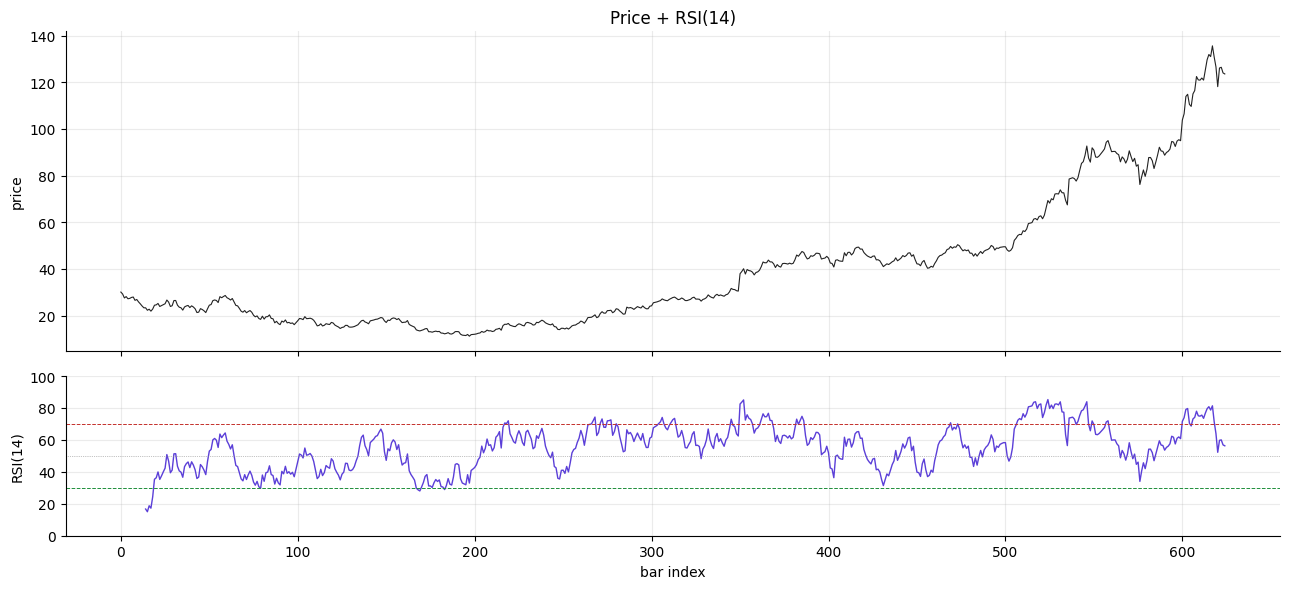

In [6]:
r14 = rsi(c, window=14)

fig, (ax_p, ax_r) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(13, 6))
ax_p.plot(x, c, color='#222', lw=0.8); ax_p.set_title('Price + RSI(14)')
ax_p.set_ylabel('price')
ax_r.plot(x, r14, color='#5b3fd8', lw=1.0)
ax_r.axhline(70, color='#c4302b', lw=0.7, ls='--')
ax_r.axhline(30, color='#1f8e3a', lw=0.7, ls='--')
ax_r.axhline(50, color='#888',    lw=0.5, ls=':')
ax_r.set_ylim(0, 100); ax_r.set_ylabel('RSI(14)'); ax_r.set_xlabel('bar index')
plt.tight_layout(); plt.show()


### MACD — Moving Average Convergence Divergence (Appel, 1979)

```
macd_line = EMA(close, fast=12) − EMA(close, slow=26)
signal    = EMA(macd_line, 9)
hist      = macd_line − signal
```

Three readable channels in one indicator:

* The **macd line** measures the *gap* between two EMAs: positive when
  the fast average is above the slow (uptrend), negative below.
* The **signal line** is the macd line smoothed once more — crossings
  of macd over signal are the classic entries.
* The **histogram** is `macd − signal`: zero at crossings, large in
  absolute value when momentum is accelerating. Histogram divergence
  vs price is widely watched.


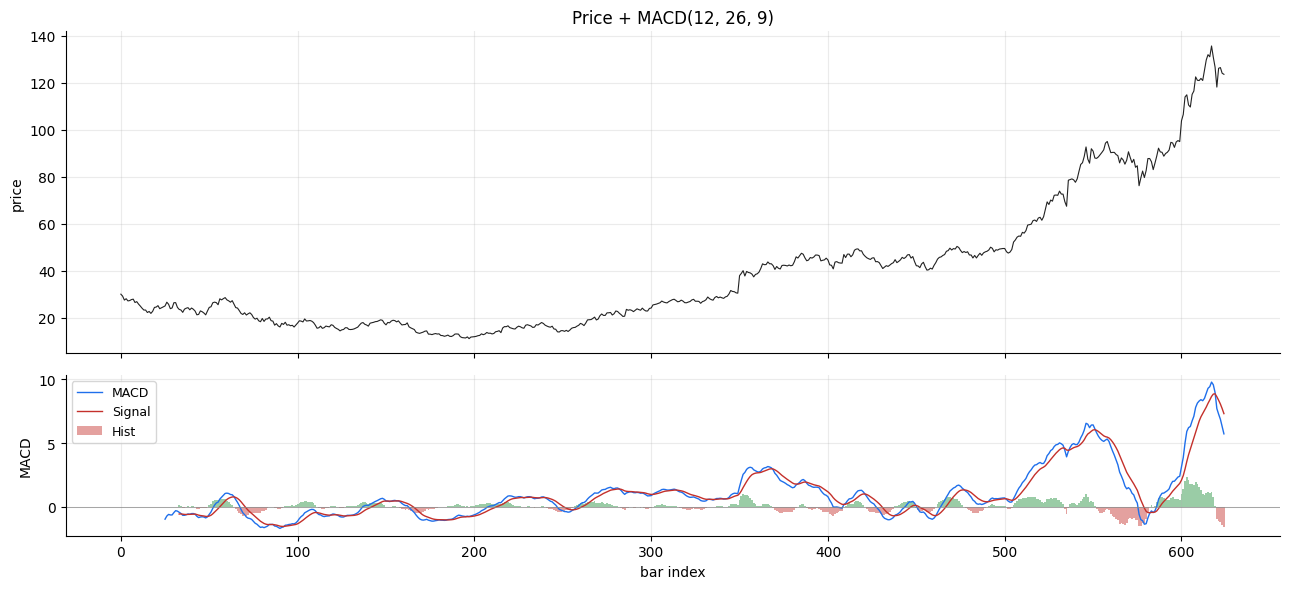

In [7]:
m = macd(c, fast=12, slow=26, signal=9)

fig, (ax_p, ax_m) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(13, 6))
ax_p.plot(x, c, color='#222', lw=0.8); ax_p.set_title('Price + MACD(12, 26, 9)')
ax_p.set_ylabel('price')
ax_m.plot(x, m.macd,   color='#1f6feb', lw=1.0, label='MACD')
ax_m.plot(x, m.signal, color='#c4302b', lw=1.0, label='Signal')
colors = np.where(m.hist >= 0.0, COLOR_UP, COLOR_DN)
ax_m.bar(x, m.hist, color=colors, width=1.0, alpha=0.45, label='Hist')
ax_m.axhline(0, color='#888', lw=0.5)
ax_m.set_ylabel('MACD'); ax_m.set_xlabel('bar index'); ax_m.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


### Stochastic — where is the close inside its recent range?

`%K = 100 · (close − low_w) / (high_w − low_w)`, smoothed by an SMA(d).
`%D = SMA(%K, d_window)` is the slower, less noisy line.

Stochastic measures *positional* momentum: where the close sits inside
the recent high-low envelope. It saturates at 100 when the close prints
at the rolling high and at 0 at the rolling low. Conventional thresholds
80/20.

Unlike RSI, %K can flatline at extremes for many bars in a strong trend
— the *crossover of %K and %D* away from an extreme is usually a
cleaner signal than the level itself.


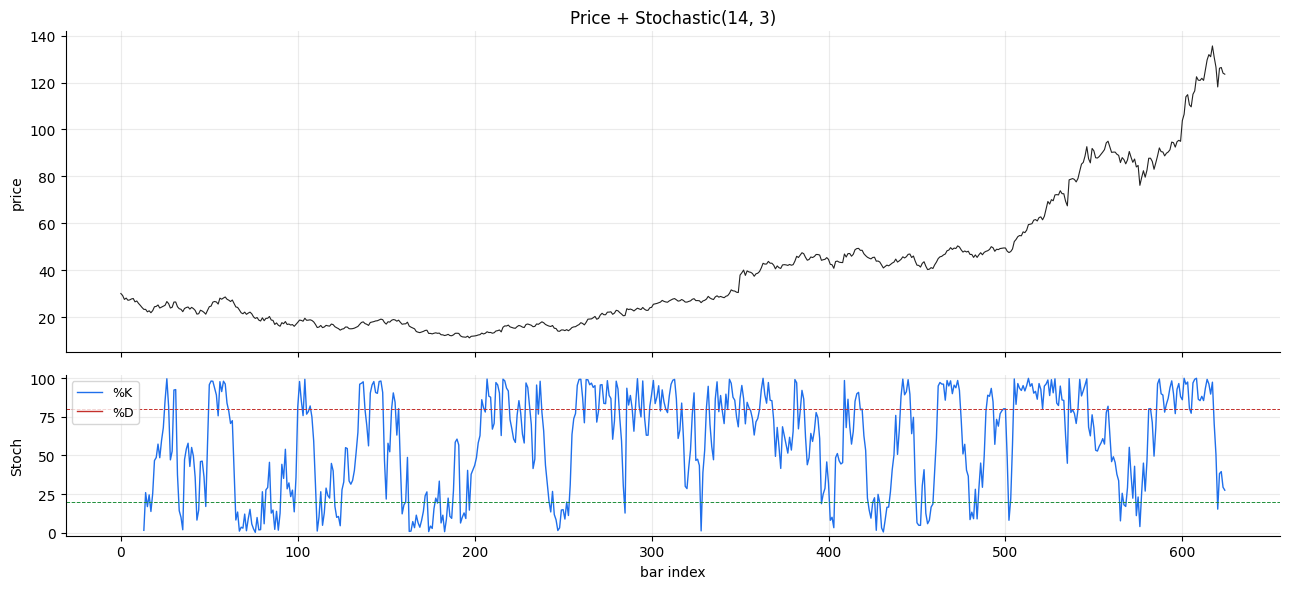

In [8]:
s = stochastic(h, l, c, k_window=14, d_window=3)

fig, (ax_p, ax_s) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(13, 6))
ax_p.plot(x, c, color='#222', lw=0.8); ax_p.set_title('Price + Stochastic(14, 3)')
ax_p.set_ylabel('price')
ax_s.plot(x, s.k, color='#1f6feb', lw=1.0, label='%K')
ax_s.plot(x, s.d, color='#c4302b', lw=1.0, label='%D')
ax_s.axhline(80, color='#c4302b', lw=0.7, ls='--')
ax_s.axhline(20, color='#1f8e3a', lw=0.7, ls='--')
ax_s.set_ylim(-2, 102); ax_s.set_ylabel('Stoch'); ax_s.set_xlabel('bar index')
ax_s.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


### ROC, CCI, Williams %R — three quick reads

* **ROC(w)** = `100 · (close_t / close_{t−w} − 1)` — the raw percent
  change over `w` bars. Unbounded; useful as a momentum *input*
  rather than for thresholding.
* **CCI(w)** — Commodity Channel Index. Z-score-like measure of the
  *typical price* `(H+L+C)/3` against its SMA, scaled by mean absolute
  deviation. Outside `±100` is the conventional "trending" band.
* **Williams %R(w)** = `−100 · (high_w − close) / (high_w − low_w)` —
  identical in spirit to %K but on `[−100, 0]`. Above `−20` is
  overbought.


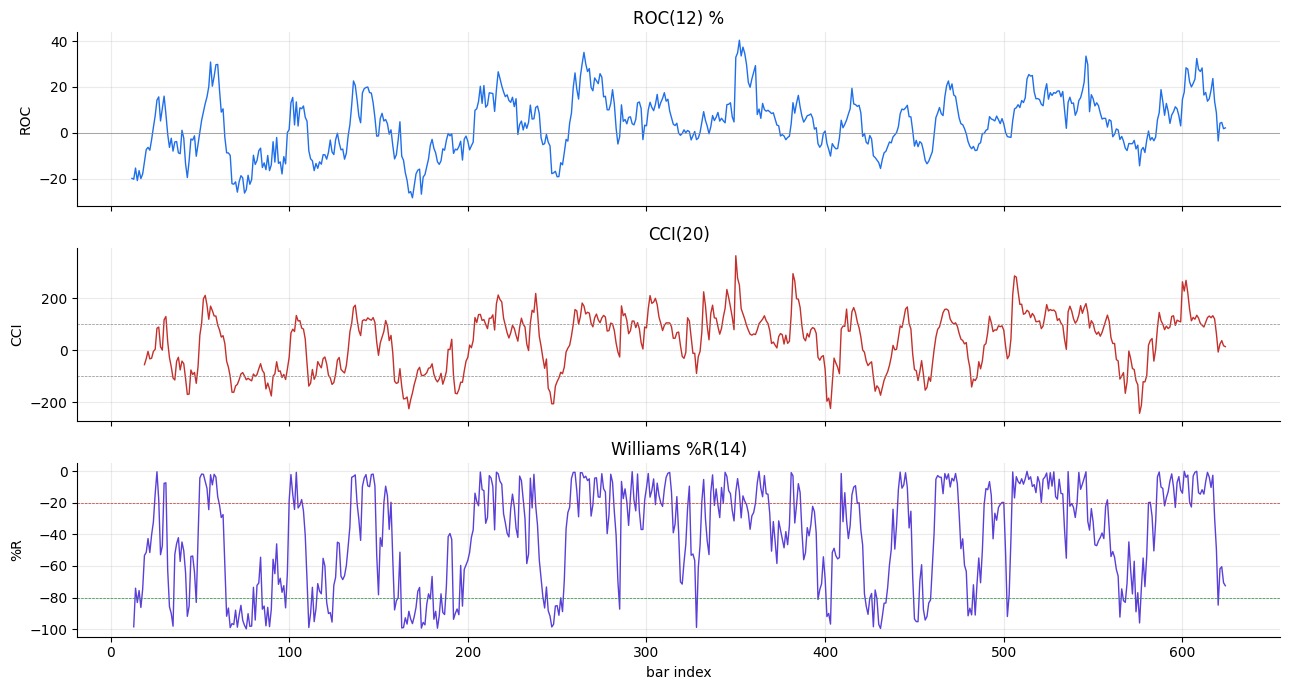

In [9]:
r = roc(c, window=12)
cc = cci(h, l, c, window=20)
wr = williams_r(h, l, c, window=14)

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(13, 7))
axes[0].plot(x, r, color='#1f6feb', lw=1.0); axes[0].axhline(0, color='#888', lw=0.5)
axes[0].set_title('ROC(12) %'); axes[0].set_ylabel('ROC')
axes[1].plot(x, cc, color='#c4302b', lw=1.0)
axes[1].axhline(100, color='#888', lw=0.5, ls='--')
axes[1].axhline(-100, color='#888', lw=0.5, ls='--')
axes[1].set_title('CCI(20)'); axes[1].set_ylabel('CCI')
axes[2].plot(x, wr, color='#5b3fd8', lw=1.0)
axes[2].axhline(-20, color='#c4302b', lw=0.5, ls='--')
axes[2].axhline(-80, color='#1f8e3a', lw=0.5, ls='--')
axes[2].set_title('Williams %R(14)'); axes[2].set_ylabel('%R'); axes[2].set_xlabel('bar index')
plt.tight_layout(); plt.show()


## 3. Volatility

Volatility indicators measure *how much* price is moving, ignoring
direction. They serve four jobs in practice:

1. **Position sizing.** Risk per trade is most naturally stated in ATR
   units. A 1×ATR stop on a high-vol day is a smaller share count than
   on a quiet day, holding dollar risk constant.
2. **Filtering.** Skip mean-reversion signals when volatility is
   contracting; skip breakouts when it's already exploded.
3. **Envelope construction.** Bollinger / Keltner / Donchian bands
   define the bar-by-bar *range* an asset normally lives in;
   breaches signal regime change.
4. **Regime detection.** Volatility itself clusters and mean-reverts —
   the input to any GARCH-style model.

### True range and ATR

The **true range** generalises a bar's high-low by including overnight
gaps:

```
TR_t = max( H_t − L_t,  |H_t − C_{t−1}|,  |L_t − C_{t−1}| )
```

**ATR** is `TR` smoothed by Wilder's recursion
`ATR_t = ((w−1)·ATR_{t−1} + TR_t) / w`, the same smoother used inside
RSI and ADX. Defaults to `window=14`.


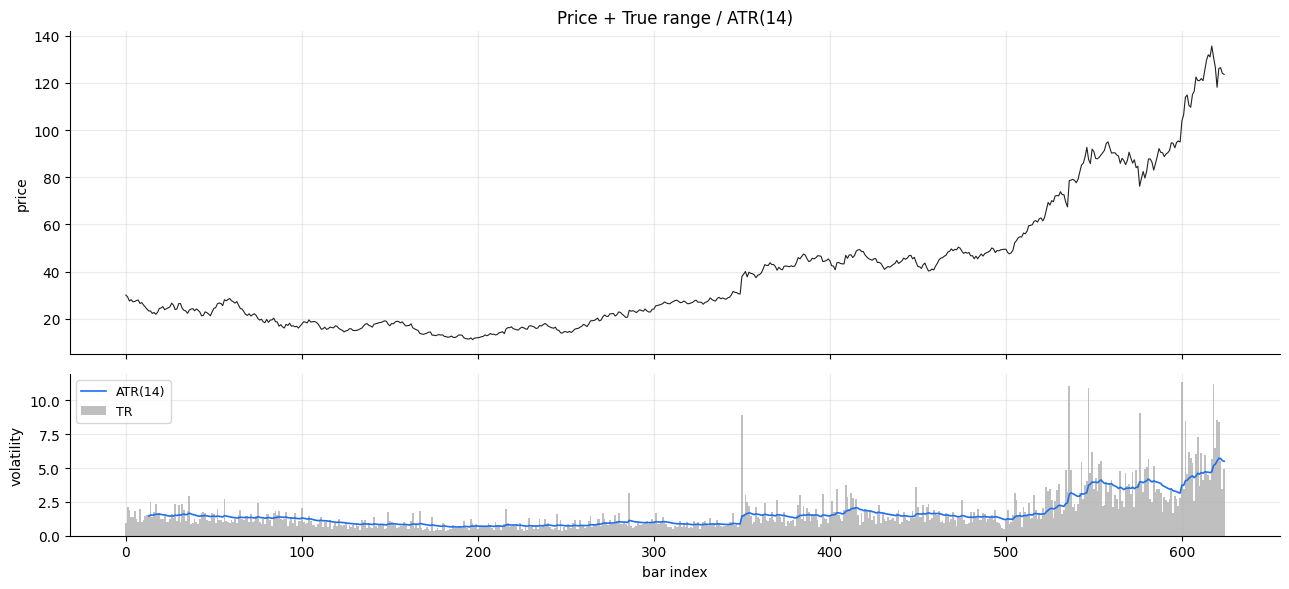

In [10]:
tr = true_range(h, l, c)
a = atr(h, l, c, window=14)

fig, (ax_p, ax_a) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(13, 6))
ax_p.plot(x, c, color='#222', lw=0.8); ax_p.set_title('Price + True range / ATR(14)')
ax_p.set_ylabel('price')
ax_a.bar(x, tr, color='#bfbfbf', width=1.0, label='TR')
ax_a.plot(x, a, color='#1f6feb', lw=1.2, label='ATR(14)')
ax_a.set_ylabel('volatility'); ax_a.set_xlabel('bar index'); ax_a.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


### Bollinger Bands — SMA ± n·σ

Bollinger Bands (John Bollinger, 1980s) wrap an SMA in a *volatility-scaled
envelope*:

```
mid   = SMA(close, 20)
sigma = rolling stddev(close, 20)
upper = mid + 2·sigma
lower = mid − 2·sigma
```

Two derived quantities are returned:

* `bandwidth = (upper − lower) / mid` — *normalised width* of the
  envelope. Low values mark a **Bollinger Squeeze**, classically a
  precursor to a directional expansion.
* `percent_b = (close − lower) / (upper − lower)` — where the close
  sits inside the band on `[0, 1]`. Touches of 0 or 1 by themselves
  aren't reversal signals; *failing to touch* after several previous
  touches often is.


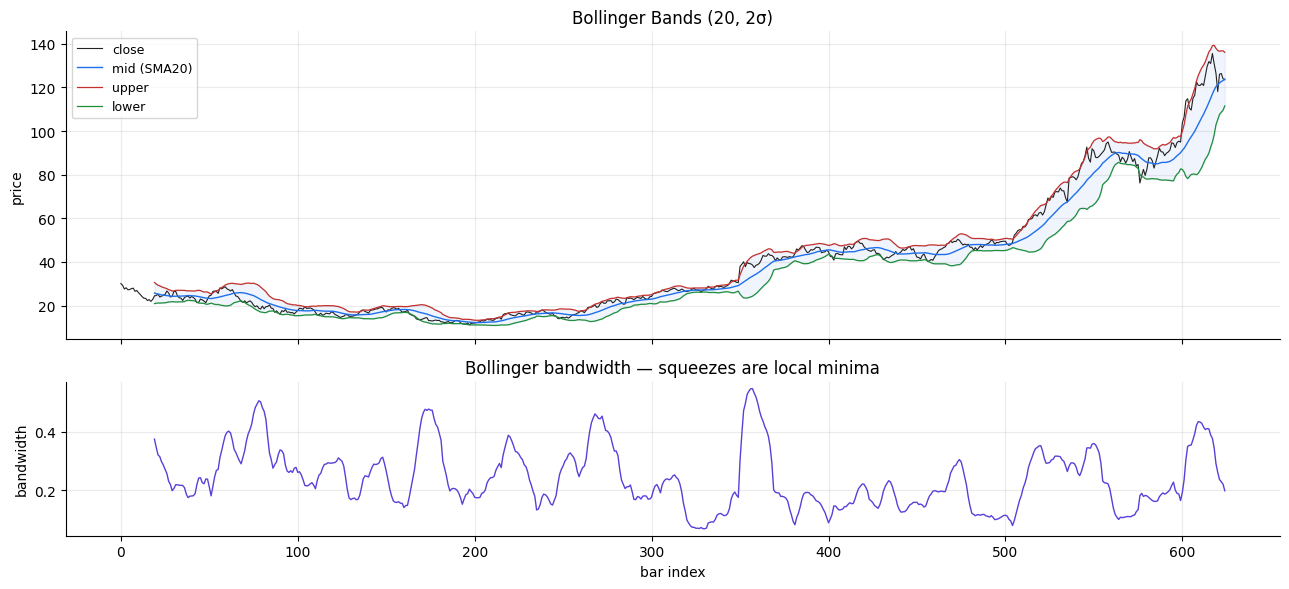

In [11]:
bb = bollinger_bands(c, window=20, n_std=2.0)

fig, (ax_p, ax_b) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(13, 6))
ax_p.plot(x, c, color='#222', lw=0.8, label='close')
ax_p.plot(x, bb.middle, color='#1f6feb', lw=1.0, label='mid (SMA20)')
ax_p.plot(x, bb.upper,  color='#c4302b', lw=0.9, label='upper')
ax_p.plot(x, bb.lower,  color='#1f8e3a', lw=0.9, label='lower')
ax_p.fill_between(x, bb.lower, bb.upper, color='#1f6feb', alpha=0.07)
ax_p.set_title('Bollinger Bands (20, 2σ)'); ax_p.set_ylabel('price')
ax_p.legend(loc='upper left', fontsize=9)
ax_b.plot(x, bb.bandwidth, color='#5b3fd8', lw=1.0)
ax_b.set_ylabel('bandwidth'); ax_b.set_xlabel('bar index')
ax_b.set_title('Bollinger bandwidth — squeezes are local minima')
plt.tight_layout(); plt.show()


### Keltner Channels — EMA ± k·ATR

Keltner Channels use the same skeleton as Bollinger but swap the SMA
for an EMA and the standard deviation for ATR. The bands are therefore
smoother (no σ regime-switching artefacts) and respond to *range*
volatility rather than *close-to-close* volatility.

A widely used setup is the **TTM Squeeze**: Bollinger bands *inside*
Keltner bands marks an unusually quiet period and often resolves with a
directional thrust.


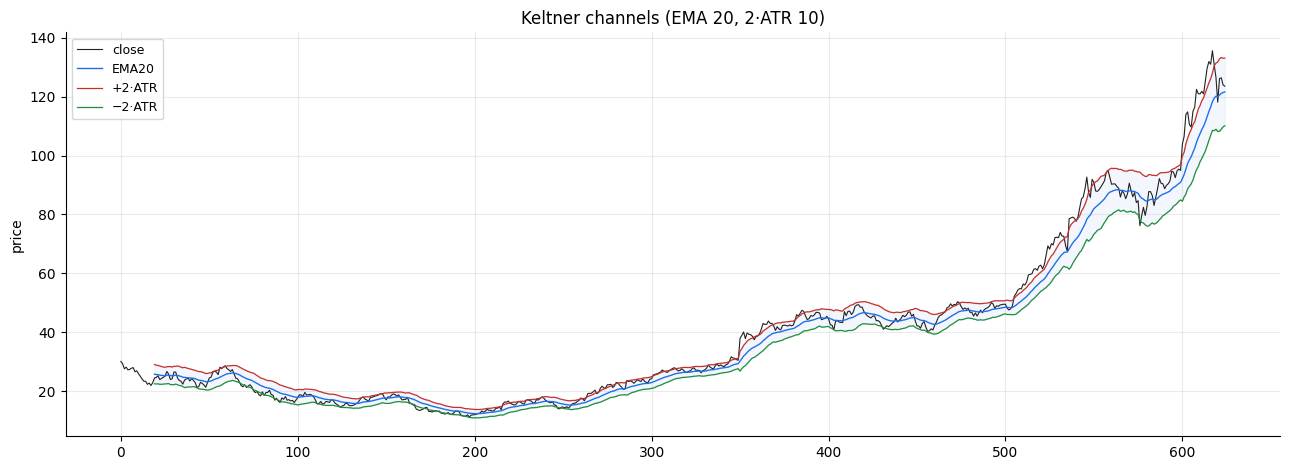

In [12]:
kc = keltner_channels(h, l, c, window=20, atr_window=10, atr_mult=2.0)

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(x, c, color='#222', lw=0.8, label='close')
ax.plot(x, kc.middle, color='#1f6feb', lw=1.0, label='EMA20')
ax.plot(x, kc.upper,  color='#c4302b', lw=0.9, label='+2·ATR')
ax.plot(x, kc.lower,  color='#1f8e3a', lw=0.9, label='−2·ATR')
ax.fill_between(x, kc.lower, kc.upper, color='#1f6feb', alpha=0.05)
ax.set_title('Keltner channels (EMA 20, 2·ATR 10)'); ax.set_ylabel('price')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


### Donchian Channels — highest-high / lowest-low

The simplest envelope of all: the rolling max of the high and rolling
min of the low. Famously the breakout signal in the *Turtle Trader*
system (close above the 20-bar high → long).


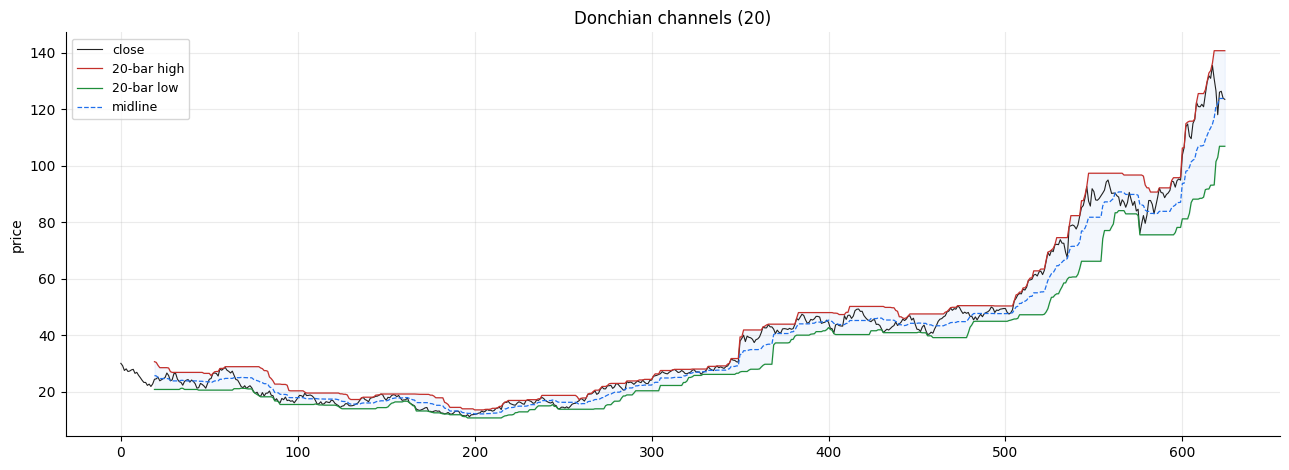

In [13]:
dc = donchian_channels(h, l, window=20)

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(x, c, color='#222', lw=0.8, label='close')
ax.plot(x, dc.upper,  color='#c4302b', lw=0.9, label='20-bar high')
ax.plot(x, dc.lower,  color='#1f8e3a', lw=0.9, label='20-bar low')
ax.plot(x, dc.middle, color='#1f6feb', lw=0.9, ls='--', label='midline')
ax.fill_between(x, dc.lower, dc.upper, color='#1f6feb', alpha=0.05)
ax.set_title('Donchian channels (20)'); ax.set_ylabel('price')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## 4. Trend / directional indicators

Before *trading* a trend you need to know whether one exists. Trend
indicators answer that question by quantifying directional persistence
in price.

### ADX — Average Directional Index (Wilder)

ADX is derived from two intermediate series:

* `+DM_t = max(H_t − H_{t-1}, 0)` if up move > down move, else 0
* `−DM_t = max(L_{t-1} − L_t, 0)` if down move > up move, else 0

Wilder-smoothed and normalised by ATR yields `+DI` and `−DI`. Then:

```
DX  = 100 · |+DI − −DI| / (+DI + −DI)
ADX = Wilder-smooth(DX, window)
```

ADX measures **strength**, *not direction*. Two conventional reads:

* `ADX > 25` → trend present, regardless of sign. `ADX > 40` is strong.
* `+DI > −DI` → up trend; `−DI > +DI` → down trend. Crossovers can
  be entries but are noisy on their own.


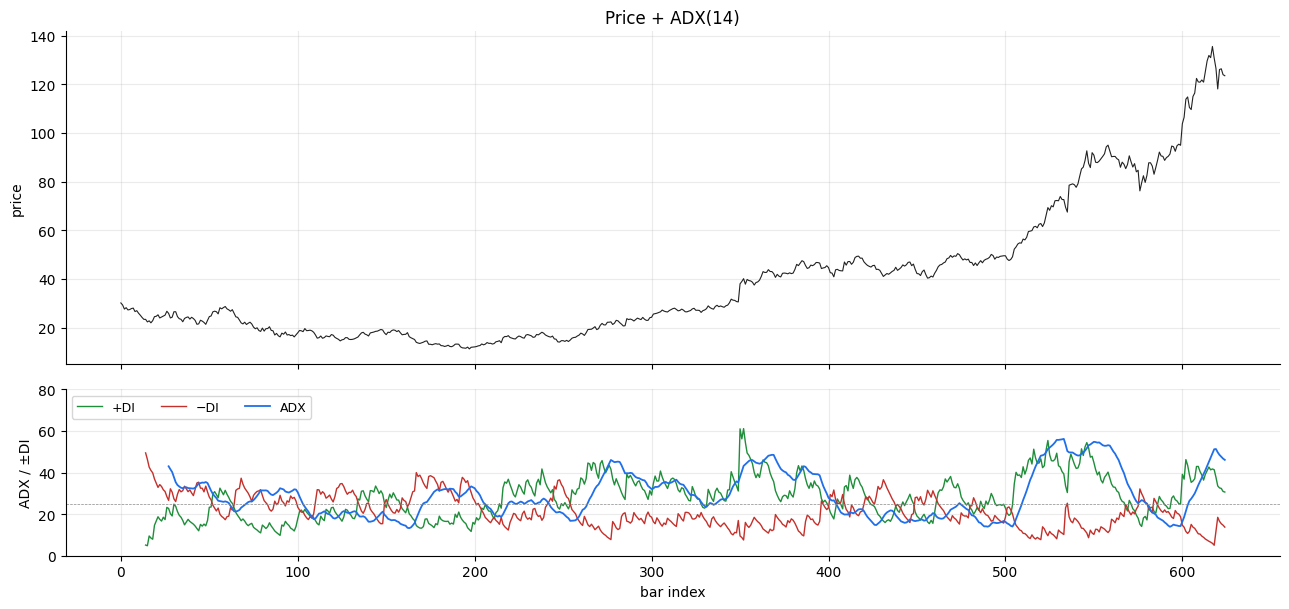

In [14]:
ad = adx(h, l, c, window=14)

fig, (ax_p, ax_d) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(13, 6.2))
ax_p.plot(x, c, color='#222', lw=0.8); ax_p.set_title('Price + ADX(14)')
ax_p.set_ylabel('price')
ax_d.plot(x, ad.plus_di,  color='#1f8e3a', lw=1.0, label='+DI')
ax_d.plot(x, ad.minus_di, color='#c4302b', lw=1.0, label='−DI')
ax_d.plot(x, ad.adx,      color='#1f6feb', lw=1.3, label='ADX')
ax_d.axhline(25, color='#888', lw=0.5, ls='--')
ax_d.set_ylim(0, 80); ax_d.set_ylabel('ADX / ±DI'); ax_d.set_xlabel('bar index')
ax_d.legend(loc='upper left', fontsize=9, ncol=3)
plt.tight_layout(); plt.show()


### Aroon — bars since high vs bars since low

`AroonUp = 100·(w − bars_since_high) / w` and the dual for `AroonDown`.
Both live on `[0, 100]`. The *oscillator* `up − down` is symmetric
around zero.

Aroon is one of the few indicators that *peaks at the start of a trend*
rather than after — useful as an early signal where ADX is still
warming up.


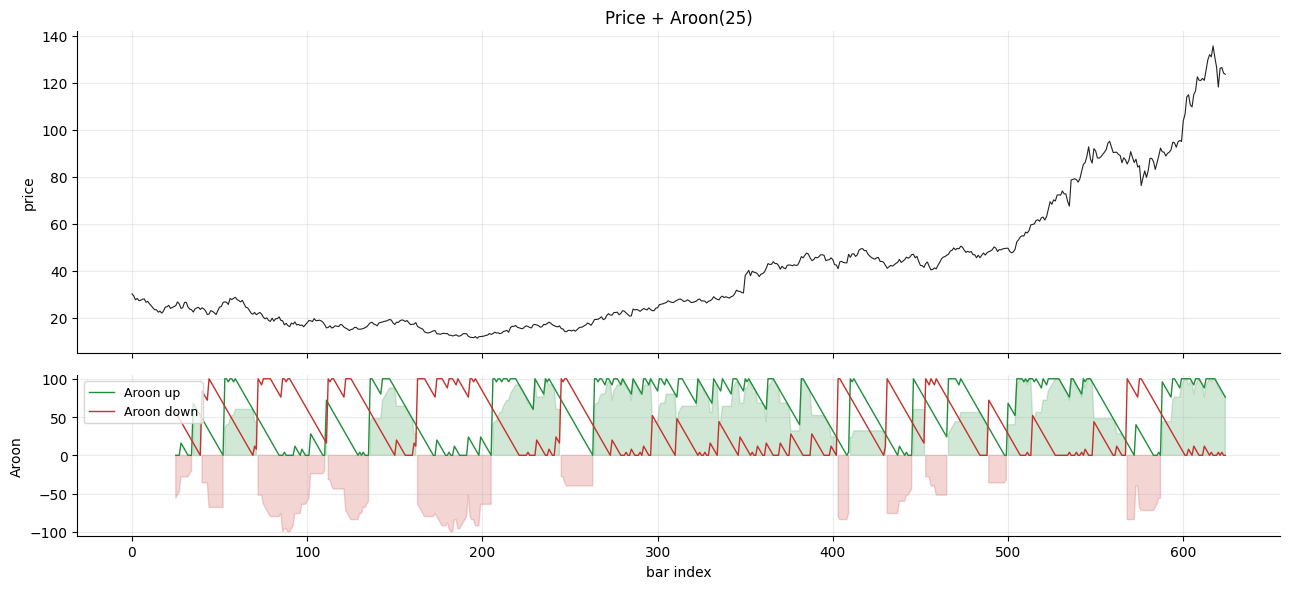

In [15]:
ar = aroon(h, l, window=25)

fig, (ax_p, ax_a) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(13, 6))
ax_p.plot(x, c, color='#222', lw=0.8); ax_p.set_title('Price + Aroon(25)')
ax_p.set_ylabel('price')
ax_a.plot(x, ar.up,   color='#1f8e3a', lw=1.0, label='Aroon up')
ax_a.plot(x, ar.down, color='#c4302b', lw=1.0, label='Aroon down')
ax_a.fill_between(x, 0, ar.oscillator,
                  where=ar.oscillator >= 0, color='#1f8e3a', alpha=0.2)
ax_a.fill_between(x, 0, ar.oscillator,
                  where=ar.oscillator < 0, color='#c4302b', alpha=0.2)
ax_a.set_ylim(-105, 105); ax_a.set_ylabel('Aroon'); ax_a.set_xlabel('bar index')
ax_a.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


### Parabolic SAR — stop and reverse

Wilder's Parabolic SAR places a *trailing stop* on each bar that
accelerates toward price as the trend ages. Each new extreme in the
direction of the trend bumps the **acceleration factor** by `af_step`
(default 0.02), capped at `af_max` (default 0.20). When the SAR is hit,
the trend flips and the AF resets.

The SAR is a *trend-following* tool: it works beautifully in clean
trends and chops you to ribbons in ranges. Pair with ADX > 25 as a
regime filter.


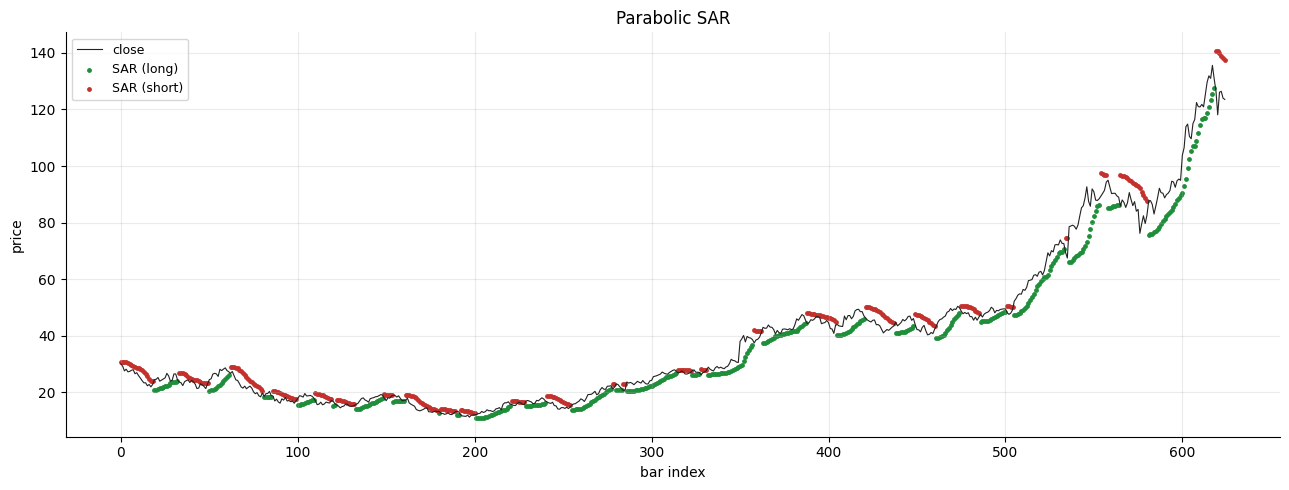

In [16]:
sar = parabolic_sar(h, l, af_start=0.02, af_step=0.02, af_max=0.2)
up = sar.direction == 1.0
dn = sar.direction == -1.0

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x, c, color='#222', lw=0.8, label='close')
ax.scatter(x[up], sar.line[up], color='#1f8e3a', s=6, label='SAR (long)')
ax.scatter(x[dn], sar.line[dn], color='#c4302b', s=6, label='SAR (short)')
ax.set_title('Parabolic SAR'); ax.set_ylabel('price'); ax.set_xlabel('bar index')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


### Supertrend — ATR-anchored regime line

Supertrend builds two bands around `(H + L)/2`:

```
upper = (H+L)/2 + k · ATR(w)
lower = (H+L)/2 − k · ATR(w)
```

Then it tracks the *lower* band as a trailing stop in uptrends and the
*upper* band in downtrends, flipping when the close crosses the active
band. The result is a single coloured line that lies *below* price in
uptrends and *above* in downtrends — visually similar to SAR but
smoother and less inclined to flip on minor pullbacks.


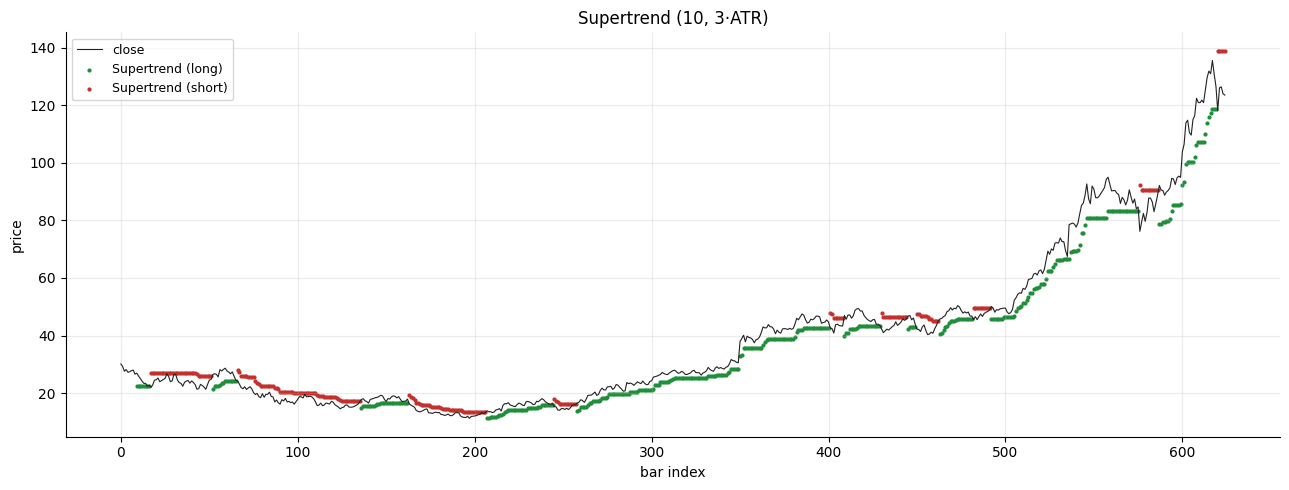

In [17]:
st = supertrend(h, l, c, window=10, multiplier=3.0)
up = st.direction == 1.0
dn = st.direction == -1.0

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x, c, color='#222', lw=0.8, label='close')
ax.scatter(x[up], st.line[up], color='#1f8e3a', s=4, label='Supertrend (long)')
ax.scatter(x[dn], st.line[dn], color='#c4302b', s=4, label='Supertrend (short)')
ax.set_title('Supertrend (10, 3·ATR)'); ax.set_ylabel('price'); ax.set_xlabel('bar index')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


### Ichimoku Kinko Hyo — a chart in one indicator

The Ichimoku Cloud (Goichi Hosoda, 1960s) bundles five components:

* **Tenkan-sen** (conversion): `(highest_high_9 + lowest_low_9) / 2`
* **Kijun-sen** (base): `(highest_high_26 + lowest_low_26) / 2`
* **Senkou Span A** (leading): `(Tenkan + Kijun)/2`, *shifted +26 bars*
* **Senkou Span B** (leading): `(HH_52 + LL_52)/2`, *shifted +26 bars*
* **Chikou Span** (lagging): close, *shifted −26 bars*

The shaded region between Senkou A and B is the **Kumo (cloud)** —
a forward-projected support/resistance zone. Standard reads:

* Price above the cloud → uptrend; below → downtrend; inside → no trend.
* Tenkan/Kijun crossover plays the same role as a fast/slow MA cross.
* The cloud *colour* (A > B is bullish, A < B is bearish) gives the
  longer-term bias.


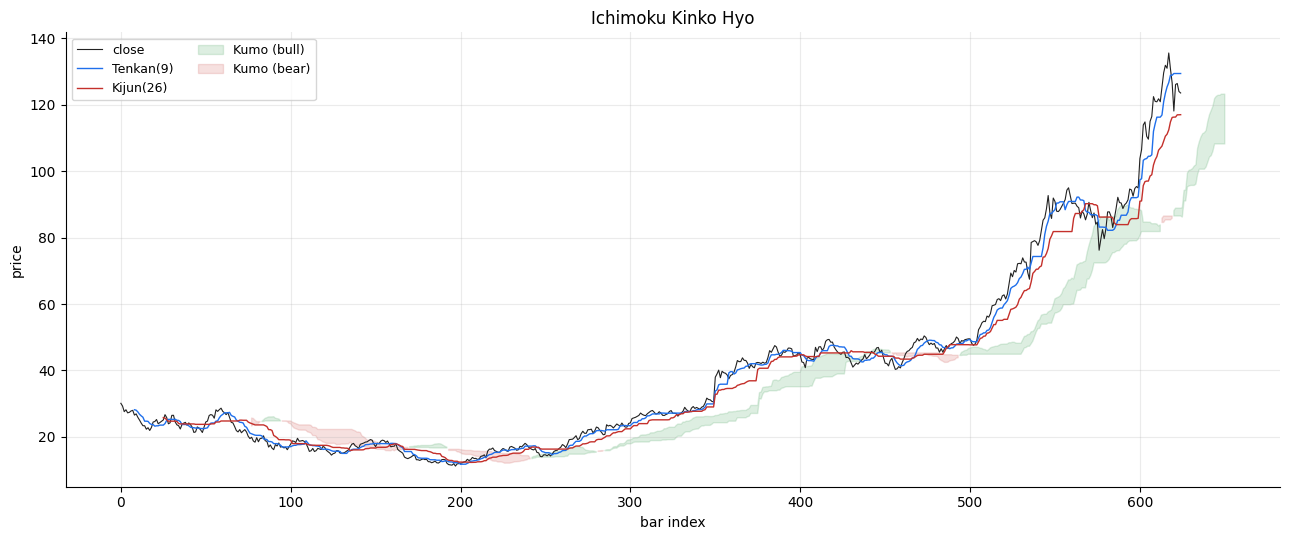

In [18]:
ic = ichimoku(h, l, c)
xs_span = np.arange(len(ic.senkou_a))

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(x, c, color='#222', lw=0.8, label='close')
ax.plot(x, ic.tenkan, color='#1f6feb', lw=1.0, label='Tenkan(9)')
ax.plot(x, ic.kijun,  color='#c4302b', lw=1.0, label='Kijun(26)')
bullish = ic.senkou_a >= ic.senkou_b
ax.fill_between(xs_span, ic.senkou_a, ic.senkou_b,
                where=bullish, color='#1f8e3a', alpha=0.15, label='Kumo (bull)')
ax.fill_between(xs_span, ic.senkou_a, ic.senkou_b,
                where=~bullish, color='#c4302b', alpha=0.15, label='Kumo (bear)')
ax.set_title('Ichimoku Kinko Hyo'); ax.set_ylabel('price'); ax.set_xlabel('bar index')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout(); plt.show()


## 5. Volume indicators

Volume is the second axis of every bar chart. A price move on heavy
volume reflects conviction; on light volume, indifference. Volume
indicators turn that intuition into a quantitative signal.

### OBV — On-Balance Volume

```
OBV_t = OBV_{t-1} + sign(close_t − close_{t-1}) · volume_t
```

A cumulative running tally that adds volume on up days and subtracts it
on down days. **Divergence** of OBV from price (price makes a higher
high while OBV does not) is the canonical read — it claims new highs
are happening on thinner participation.

OBV's level is meaningless (it depends on the starting point). Only the
*slope* and *divergences* matter.


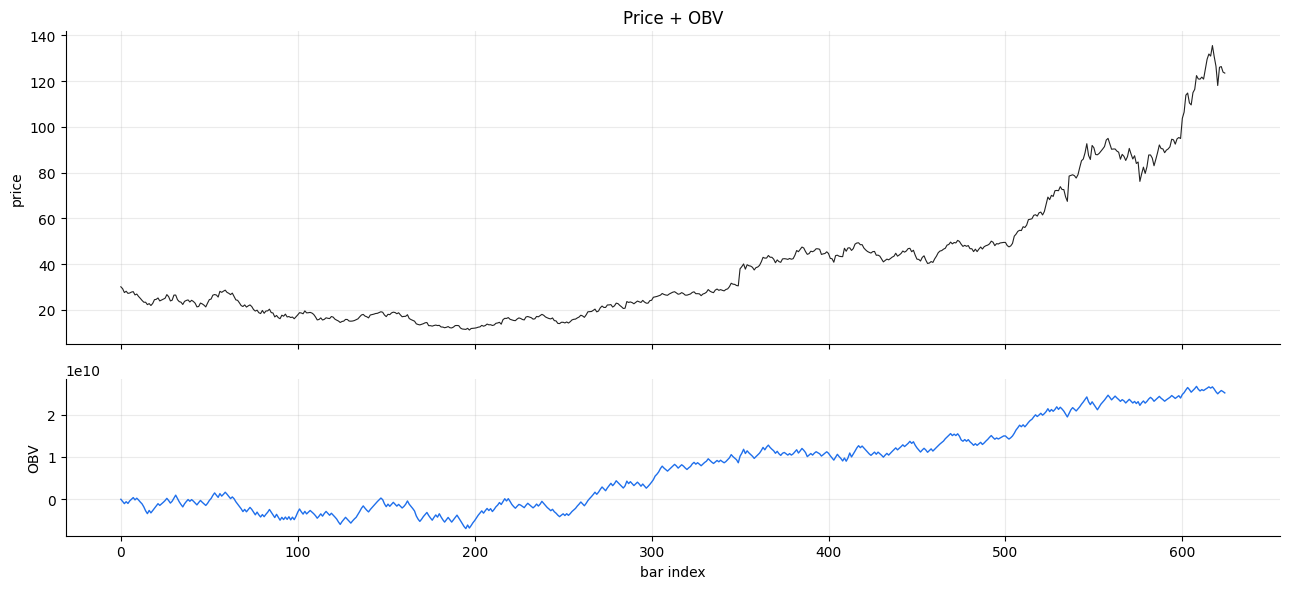

In [19]:
o_obv = obv(c, v)

fig, (ax_p, ax_o) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(13, 6))
ax_p.plot(x, c, color='#222', lw=0.8); ax_p.set_title('Price + OBV')
ax_p.set_ylabel('price')
ax_o.plot(x, o_obv, color='#1f6feb', lw=1.0)
ax_o.set_ylabel('OBV'); ax_o.set_xlabel('bar index')
plt.tight_layout(); plt.show()


### VWAP — Volume-Weighted Average Price

Cumulative VWAP weights the typical price `(H+L+C)/3` by traded volume:

```
VWAP_t = Σ_{k≤t} TP_k · V_k  /  Σ_{k≤t} V_k
```

Institutional execution algorithms benchmark fills against VWAP — a buy
filled *below* the day's VWAP is "better than average". Intraday VWAP
(reset at the open) is the most widely watched intraday level; we show
the cumulative version on daily data here for illustration, plus a
*rolling* VWAP that decays the lookback window.


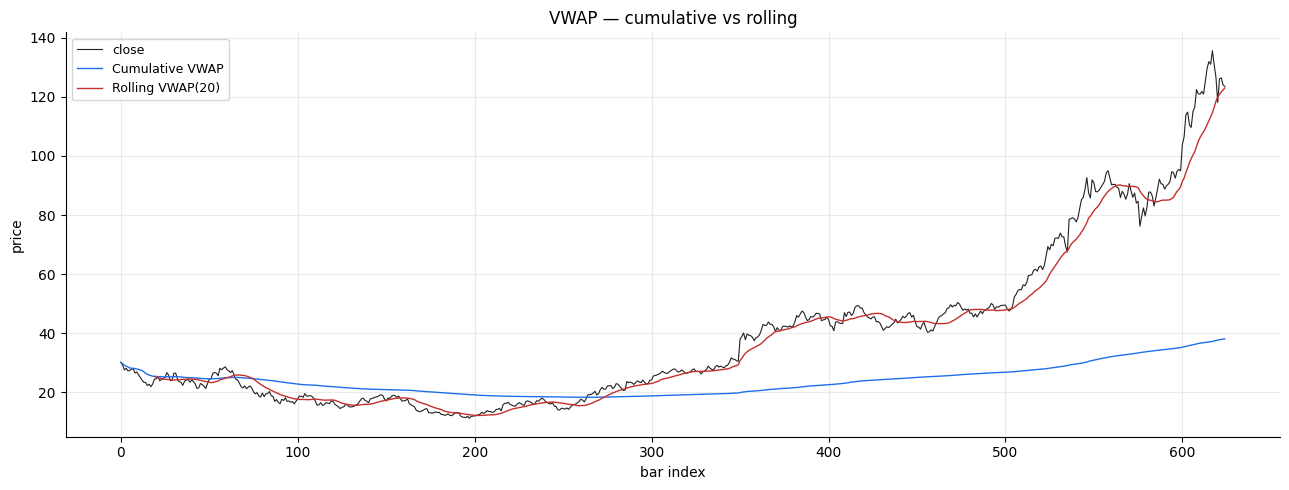

In [20]:
vw = vwap(h, l, c, v)
rvw = rolling_vwap(h, l, c, v, window=20)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x, c, color='#222', lw=0.8, label='close')
ax.plot(x, vw,  color='#1f6feb', lw=1.0, label='Cumulative VWAP')
ax.plot(x, rvw, color='#c4302b', lw=1.0, label='Rolling VWAP(20)')
ax.set_title('VWAP — cumulative vs rolling')
ax.set_ylabel('price'); ax.set_xlabel('bar index')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


### MFI, CMF, A/D — the volume-weighted oscillators

* **MFI** — Money Flow Index. RSI computed on `TP · V` instead of on
  close changes. Bounded `[0, 100]`; 80/20 thresholds. Reacts to
  *price moves weighted by volume*.
* **CMF** — Chaikin Money Flow. Rolling sum of *money flow volume*
  (a per-bar `[−1, 1]` location of the close inside the high-low range,
  times volume) divided by rolling volume. Positive readings indicate
  buying pressure.
* **A/D line** — Accumulation/Distribution. Cumulative money-flow volume.
  Same intuition as OBV but using the close's *position within the bar*
  rather than the close-to-close direction.


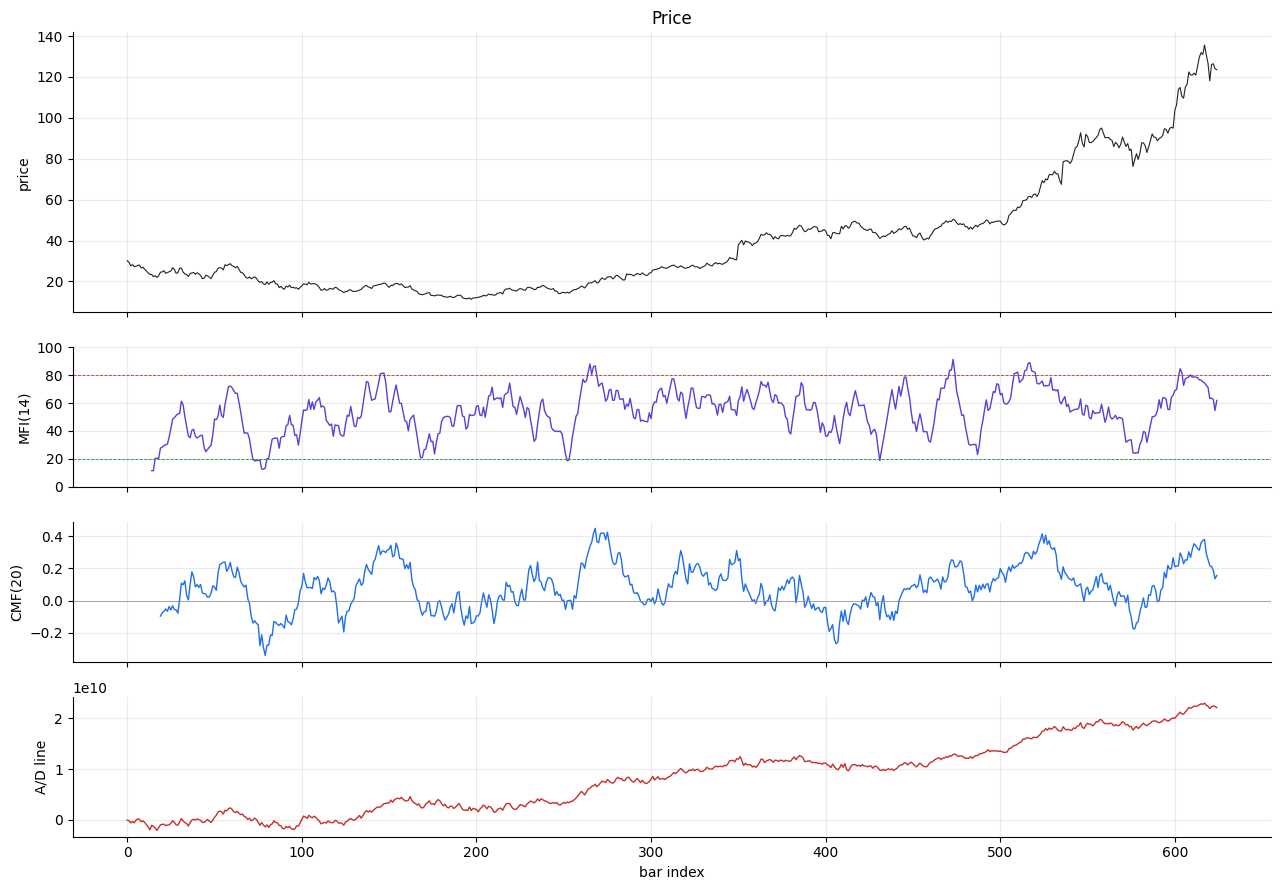

In [21]:
mf = mfi(h, l, c, v, window=14)
cm = cmf(h, l, c, v, window=20)
ad = accumulation_distribution(h, l, c, v)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(13, 9), height_ratios=[2, 1, 1, 1])
axes[0].plot(x, c, color='#222', lw=0.8); axes[0].set_title('Price'); axes[0].set_ylabel('price')
axes[1].plot(x, mf, color='#5b3fd8', lw=1.0)
axes[1].axhline(80, color='#c4302b', lw=0.6, ls='--')
axes[1].axhline(20, color='#1f8e3a', lw=0.6, ls='--')
axes[1].set_ylim(0, 100); axes[1].set_ylabel('MFI(14)')
axes[2].plot(x, cm, color='#1f6feb', lw=1.0); axes[2].axhline(0, color='#888', lw=0.5)
axes[2].set_ylabel('CMF(20)')
axes[3].plot(x, ad, color='#c4302b', lw=1.0)
axes[3].set_ylabel('A/D line'); axes[3].set_xlabel('bar index')
plt.tight_layout(); plt.show()


## 6. Support and resistance

Horizontal price levels at which the market has repeatedly transacted
attract orders for both behavioural reasons (anchoring, prior pain,
round numbers) and structural reasons (option strikes, stop placement).
This package builds them two complementary ways.

### Floor pivots — deterministic levels from the prior bar

Computed from the previous bar's high, low and close:

```
PP = (H + L + C) / 3
R1 = 2·PP − L          S1 = 2·PP − H
R2 = PP + (H − L)      S2 = PP − (H − L)
R3 = H + 2·(PP − L)    S3 = L − 2·(H − PP)
```

The **Fibonacci** variant places R/S at 0.382, 0.618, 1.0 times the
prior range. Pivots are most widely used intraday on equity-index
futures — a clean structural anchor for day-trading systems.


In [22]:
row = bars.data.tail(2).head(1).to_dicts()[0]
pp_classic = pivot_points(prev_high=row['high'], prev_low=row['low'], prev_close=row['close'])
pp_fib     = fibonacci_pivot_points(prev_high=row['high'], prev_low=row['low'], prev_close=row['close'])

print('Classic pivots:')
for k, val in pp_classic.as_dict().items():
    print(f'  {k:>3} = {val:9.2f}')
print('\nFibonacci pivots:')
for k, val in pp_fib.as_dict().items():
    print(f'  {k:>3} = {val:9.2f}')


Classic pivots:
   PP =    124.44
   R1 =    125.96
   R2 =    127.93
   R3 =    129.45
   S1 =    122.47
   S2 =    120.95
   S3 =    118.98

Fibonacci pivots:
   PP =    124.44
   R1 =    125.77
   R2 =    126.60
   R3 =    127.93
   S1 =    123.11
   S2 =    122.28
   S3 =    120.95


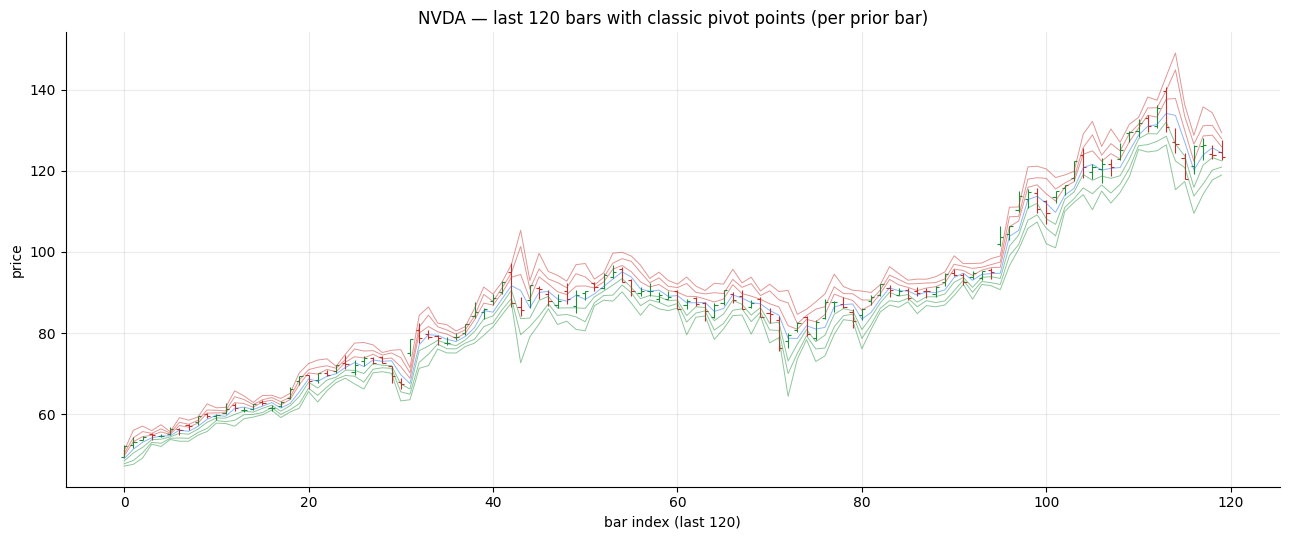

In [23]:
series = pivot_points_series(h, l, c, method='classic')
window_x = x[-120:]

fig, ax = plt.subplots(figsize=(13, 5.5))
plot_ohlc(ax, bars.slice_bars(n - 120, n))
last = n - 120
for level, color in [('PP', '#1f6feb'),
                     ('R1', '#c4302b'), ('R2', '#c4302b'), ('R3', '#c4302b'),
                     ('S1', '#1f8e3a'), ('S2', '#1f8e3a'), ('S3', '#1f8e3a')]:
    ax.plot(np.arange(120), series[level][last:], color=color, lw=0.7, alpha=0.5)
ax.set_title(f'{bars.symbol} — last 120 bars with classic pivot points (per prior bar)')
ax.set_ylabel('price'); ax.set_xlabel('bar index (last 120)')
plt.tight_layout(); plt.show()


### Swing clustering — emergent S/R from pivot histograms

A more empirical method: detect swing pivots from the bar series, then
cluster them by proximity in *price*. A cluster of multiple swings near
the same level is exactly what makes that level *psychologically real*.

`support_resistance_from_swings` takes a list of `SwingPoint` objects
(produced by `qufin.wyckoff.find_swings`) and returns a list of
`SupportResistanceLevel` records, sorted by descending strength. Each
level carries:

* `price` — cluster centroid
* `kind` — `'S'` (only lows merged), `'R'` (only highs), `'SR'` (both)
* `touches` — number of pivots merged
* `strength` — `touches × mean pivot strength`
* `first_idx`, `last_idx` — chronology of the cluster

Levels touched repeatedly *and* across a long time span are the most
reliable. The `tolerance` parameter (relative price gap, e.g. `0.01`
= 1 %) tunes how aggressively nearby swings are merged.


In [24]:
swings = find_swings(bars, left=5, right=5)
levels = support_resistance_from_swings(swings, tolerance=0.02)
top = levels[:8]
print(f'detected {len(swings)} swings → {len(levels)} clusters; top 8 by strength:')
for lev in top:
    print(
        f'  price={lev.price:8.2f}  kind={lev.kind:>2}  '
        f'touches={lev.touches:>2}  strength={lev.strength:5.2f}  '
        f'first={lev.first_idx:>4}  last={lev.last_idx:>4}'
    )


detected 71 swings → 41 clusters; top 8 by strength:
  price=   47.60  kind=SR  touches= 4  strength=20.00  first= 383  last= 502
  price=   14.04  kind=SR  touches= 3  strength=15.00  first= 125  last= 254
  price=   18.27  kind=SR  touches= 3  strength=15.00  first=  79  last= 137
  price=   20.49  kind=SR  touches= 3  strength=15.00  first=  44  last= 285
  price=   50.42  kind= R  touches= 3  strength=15.00  first= 412  last= 492
  price=   13.77  kind=SR  touches= 2  strength=10.00  first= 191  last= 248
  price=   14.51  kind=SR  touches= 2  strength=10.00  first= 131  last= 173
  price=   15.20  kind= S  touches= 2  strength=10.00  first= 115  last= 223


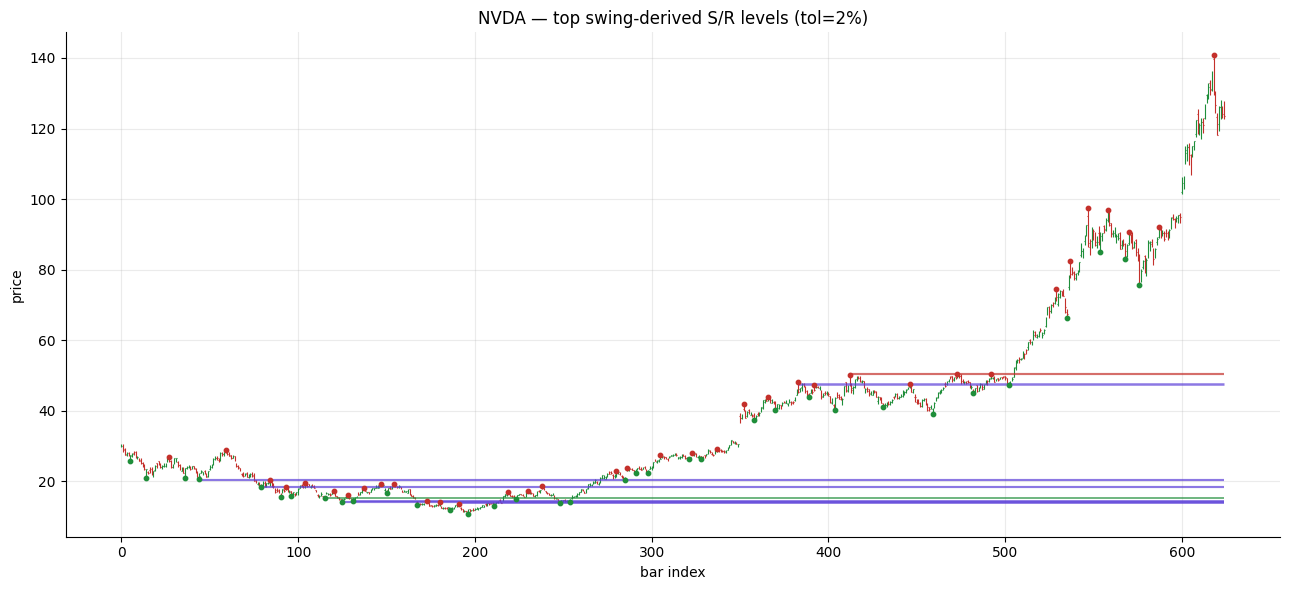

In [25]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_ohlc(ax, bars)
for lev in top:
    color = '#c4302b' if lev.kind == 'R' else '#1f8e3a' if lev.kind == 'S' else '#5b3fd8'
    ax.hlines(
        lev.price, lev.first_idx, n - 1,
        color=color, lw=0.8 + 0.25 * min(lev.touches, 6), alpha=0.7,
    )
for s in swings:
    color = '#c4302b' if s.kind == 'H' else '#1f8e3a'
    ax.scatter(s.idx, s.price, color=color, s=10, zorder=5)
ax.set_title(f'{bars.symbol} — top swing-derived S/R levels (tol=2%)')
ax.set_ylabel('price'); ax.set_xlabel('bar index')
plt.tight_layout(); plt.show()


## What next?

You now have a working tour of every indicator in `qufin.indicators`.
A few directions to explore from here:

* **Combine indicators into rule-based strategies.** A classic toy
  system: long when `close > EMA(200)`, `ADX > 25`, and Supertrend
  flips to long. Backtest on the OHLCV series above.
* **Use them as ML features.** The numpy outputs are ready-made
  features for tree models or neural nets — typically with the warm-up
  NaNs dropped or imputed.
* **Tune the windows.** Most of the defaults (14, 20, 26) are historic
  conventions, not optimums. Cross-validated grid search over `(window,
  multiplier)` pairs is the right way to pick.
* **Combine with the Wyckoff subpackage.** The swing-derived S/R levels
  in this notebook came from `qufin.wyckoff.find_swings`; volume
  profiles (`qufin.wyckoff.volume_profile`) give a complementary
  view of where price has *transacted* rather than just *pivoted*.
* **Look out for the next subpackage** — strategy backtesting and
  performance attribution built on top of these primitives.
